<a href="https://colab.research.google.com/github/ii3ruj/Academic-Technical-Projects/blob/main/lab02_csl_2310726_ruba_aljuhani.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CECS 416 – Applied Machine Learning
## Lab 02: The ML Pipeline End-to-End

**University of Jeddah — College of Computer Science and Engineering**
**Department of Computer Science and Artificial Intelligence**

---

## Student Information
- **Name:** Ruba Aljuhani
- **Student ID:** 2310726
- **Section:** CSL
- **Date:** 12/9/2026

---

## Lab Information

### Lab Description
In Lab 01 you learned to handle data. Today you will run a **complete machine learning workflow** for the first time — from raw CSV file to a trained model making predictions.

**The ML Pipeline:**

> **Get Data → Preprocess → Visualize → Split → Train → Evaluate**

Every lab for the rest of this course zooms into one or two stages of this pipeline. Today you see the whole picture.

⚠️ **Note:** Today the model itself is a *black box* — we use it without understanding its internals. Starting from Lab 03, we open the box and study each algorithm.

---

### Lab Objectives
By the end of this lab, you will be able to:

- Describe the stages of the end-to-end ML pipeline
- Encode categorical features numerically
- Select features and build the **X / y** matrices
- Split data into **training and test sets** — and explain why
- Train a classifier using **scikit-learn**
- Evaluate a model using **accuracy** on unseen data
- Diagnose the difference between training and test performance

---

### Course Learning Outcome (CLO) Mapping

**CLO 2.1 (Skill S3):**
*Integrate open-source/commercial Machine Learning libraries to develop solutions for practical problems.*

This lab supports CLO 2.1 by using **scikit-learn** — the most widely used open-source ML library — to build a complete working solution.

---

### Assessment (Mark: 1)

| Mark | Criteria |
|------|----------|
| **1.0** | Attended the lab **and** submitted a notebook that runs top-to-bottom with all homework tasks attempted correctly |
| **0.5** | Attended **or** submitted, with partial correctness or incomplete tasks |
| **0.0** | Did not attend and did not submit, or notebook does not run |

---

### Instructions
- Answer all questions directly in this notebook.
- Do **not** modify the required structure of the lab.
- Ensure the notebook runs **top-to-bottom without errors** (Runtime → Run all).
- Homework is due **before the next lab session**.

---

## 📥 Setup

We continue with the **Titanic** dataset (`train.csv`) from Lab 01. Upload it to your environment (Colab 📁 Files panel, or the notebook folder in Jupyter).

**Goal for today:** predict `Survived` (0/1) from passenger information — a **binary classification** problem.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ Libraries ready")

✅ Libraries ready


---
## 🔵 Stage 1: Get the Data

Every project starts by loading and looking at the data.

In [ ]:
df = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')
print("Shape:", df.shape)     # (rows, columns)
df.head()

Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


---
## 🔵 Stage 2: Preprocessing

ML models need **numeric, complete** data. We must:
1. Handle missing values (as in Lab 01)
2. **Encode** categorical features as numbers
3. Select the features to use

In [ ]:
# 2.1 Handle missing values (Lab 01 skill)
df['Age'] = df['Age'].fillna(df['Age'].median())

### Encoding categorical features

`Sex` contains text (`male` / `female`) — models can't process text. We **map** it to numbers:

In [ ]:
# 2.2 Encode Sex: male -> 0, female -> 1
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df[['Name', 'Sex']].head()

,Name,Sex
0,"Braund, Mr. Owen Harris",NaN
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",NaN
2,"Heikkinen, Miss. Laina",NaN
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",NaN
4,"Allen, Mr. William Henry",NaN


### Selecting features: building X and y

- **X** = the input features (what the model learns *from*)
- **y** = the target (what the model learns *to predict*)

In [ ]:
features = ['Pclass', 'Sex', 'Age', 'Fare']

X = df[features]
y = df['Survived']

print("X shape:", X.shape)
print("y shape:", y.shape)
X.head()

X shape: (891, 4)
y shape: (891,)


,Pclass,Sex,Age,Fare
0,3,NaN,22.0,7.2500
1,1,NaN,38.0,71.2833
2,3,NaN,26.0,7.9250
3,1,NaN,35.0,53.1000
4,3,NaN,35.0,8.0500


---
## 🔵 Stage 3: Visualize — Exploratory Data Analysis (EDA)

**EDA** is the practice of exploring a dataset *before* modeling — using statistics and plots to understand:

1. **What does each feature look like?** (distributions, ranges, outliers)
2. **How do features relate to the target?** (which ones carry signal?)
3. **What problems exist?** (missing values, imbalance, strange values)

> 💡 *"Garbage in, garbage out."* Models can only learn patterns that exist in the data — EDA is how you find out whether those patterns exist, before wasting time training.

### EDA Step 1: Summary statistics

In [ ]:
# One line gives you the statistical fingerprint of every numeric column
df.describe()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,0.0,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,NaN,29.361582,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,NaN,13.019697,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,NaN,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,NaN,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,NaN,80.000000,8.000000,6.000000,512.329200


**How to read this:** compare `mean` vs `50%` (median) — a big gap means skew. Look at `min`/`max` for suspicious values. For example: `Fare` max is 512 while its median is ~14 — extremely skewed, with a few very expensive tickets.

In [ ]:
# For the target: how balanced are the classes? (Lab 01 skill)
print(df['Survived'].value_counts())
print()
print((df['Survived'].value_counts(normalize=True) * 100).round(1))

Survived
0    549
1    342
Name: count, dtype: int64

Survived
0    61.6
1    38.4
Name: proportion, dtype: float64


~62% died vs ~38% survived — **moderately imbalanced**. Important context: a lazy model that predicts "died" for everyone would already score 62% accuracy! Keep this number in mind when judging Stage 6's result.

### EDA Step 2: Distributions of individual features

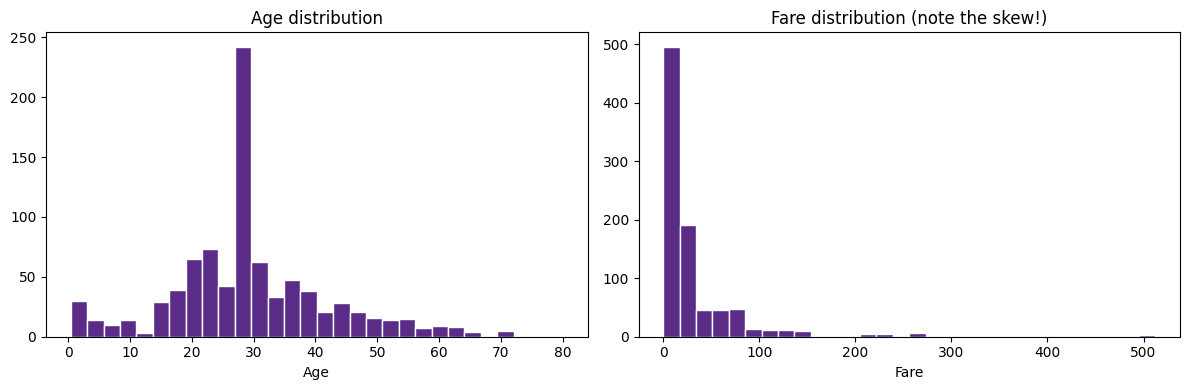

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram: what ages are aboard?
axes[0].hist(df['Age'], bins=30, color='#5B2C87', edgecolor='white')
axes[0].set_title('Age distribution')
axes[0].set_xlabel('Age')

# Histogram: what did people pay?
axes[1].hist(df['Fare'], bins=30, color='#5B2C87', edgecolor='white')
axes[1].set_title('Fare distribution (note the skew!)')
axes[1].set_xlabel('Fare')

plt.tight_layout()
plt.show()

**Observations:** Age is roughly bell-shaped centered near 30 (plus the spike at the median we created by filling missing values!). Fare is heavily right-skewed — most tickets cheap, a long tail of expensive ones.

### EDA Step 3: Features vs. the target — where is the signal?

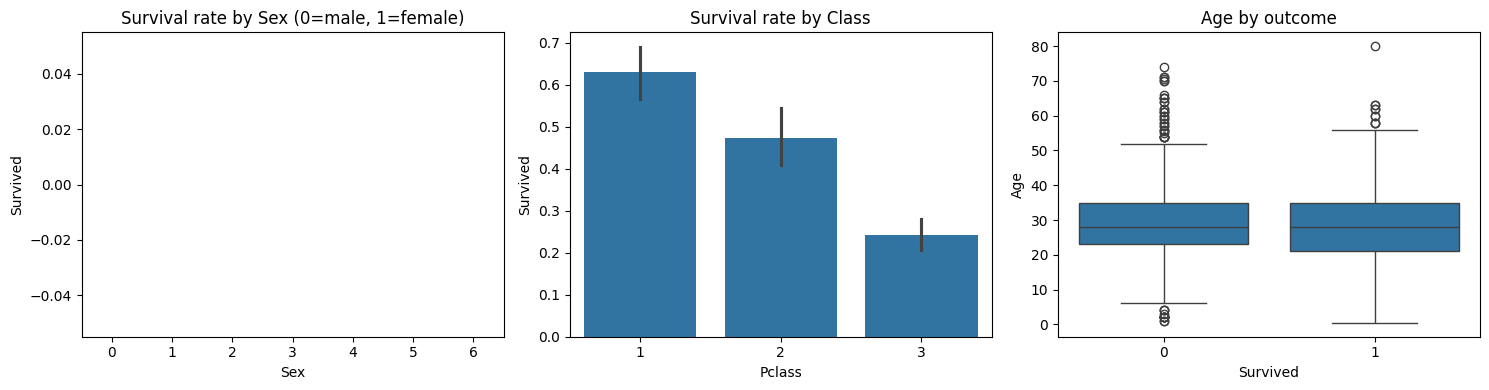

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.barplot(x='Sex', y='Survived', data=df, ax=axes[0])
axes[0].set_title('Survival rate by Sex (0=male, 1=female)')

sns.barplot(x='Pclass', y='Survived', data=df, ax=axes[1])
axes[1].set_title('Survival rate by Class')

# Age vs survival: compare distributions
sns.boxplot(x='Survived', y='Age', data=df, ax=axes[2])
axes[2].set_title('Age by outcome')

plt.tight_layout()
plt.show()

In [ ]:
# The same signal in numbers — survival rate per group
print("Survival rate by Sex:")
print(df.groupby('Sex')['Survived'].mean().round(3))
print()
print("Survival rate by Pclass:")
print(df.groupby('Pclass')['Survived'].mean().round(3))

Survival rate by Sex:
Series([], Name: Survived, dtype: float64)

Survival rate by Pclass:
Pclass
1    0.630
2    0.473
3    0.242
Name: Survived, dtype: float64


**Findings:** females survived at ~74% vs. males ~19% — `Sex` is a very strong signal. First class ~63% vs. third class ~24% — `Pclass` also matters. Age differences are subtler.

### EDA Step 4: Feature–feature relationships (correlation)

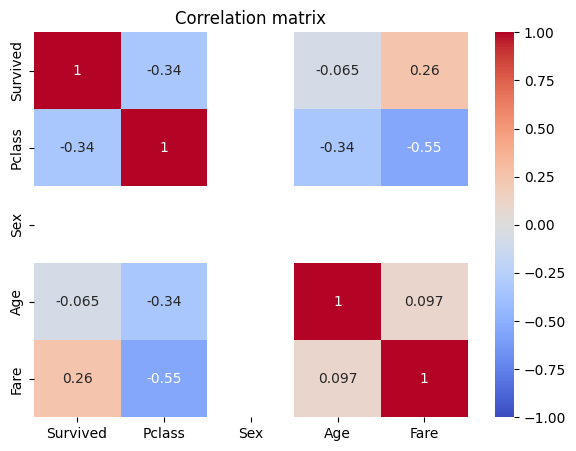

In [ ]:
plt.figure(figsize=(7, 5))
sns.heatmap(df[['Survived', 'Pclass', 'Sex', 'Age', 'Fare']].corr(),
            annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation matrix')
plt.show()

**How to read a correlation matrix:** values near **+1** move together, near **−1** move oppositely, near **0** are unrelated. Check the `Survived` row: `Sex` (+0.54) is the strongest single correlate; `Pclass` is negative (higher class number = lower survival). Also note `Pclass` vs `Fare` (−0.55): first-class tickets cost more — the features themselves are related.

### 🎯 EDA conclusions → modeling decisions

| EDA finding | Decision it informs |
|-------------|--------------------|
| Sex & Pclass strongly related to survival | Include them as features ✅ |
| Fare heavily skewed with outliers | Scaling will matter for some models (Lab 03!) |
| Classes moderately imbalanced (62/38) | Accuracy must beat the 62% "lazy baseline" |
| Age was median-filled | The spike at 28 is an artifact we created — remember it |

This is the purpose of EDA: **every plot ends in a decision.**

**❓ Think about it:** Which feature looks more predictive of survival — `Sex` or `Pclass`? What does the correlation matrix say?

---
## 🔵 Stage 4: Train/Test Split — The Golden Rule of ML

### ⚠️ The most important idea in this lab

> **Never evaluate a model on the same data it was trained on.**

A model can simply *memorize* its training data — like a student memorizing past exam answers. The real question is: does it perform well on **unseen** data?

So we split:
- **Training set (80%)** — the model learns from this
- **Test set (20%)** — hidden from the model until evaluation time

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set:", X_train.shape[0], "passengers")
print("Test set:    ", X_test.shape[0], "passengers")

Training set: 712 passengers
Test set:     179 passengers


---
## 🔵 Stage 5: Train a Model

Today the model is a **black box**: data goes in, predictions come out. (We open the box starting Lab 03.)

Every scikit-learn model follows the same 3-step recipe:
1. **Create** the model
2. **Fit** it on training data → `model.fit(X_train, y_train)`
3. **Predict** on new data → `model.predict(X_test)`

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# 1. Create
model = DecisionTreeClassifier(max_depth=3, random_state=42)

# 2. Fit (learn from training data)
model.fit(X_train, y_train)

# 3. Predict on the UNSEEN test set
y_pred = model.predict(X_test)

print("First 10 predictions:", y_pred[:10])
print("First 10 true labels:", y_test.values[:10])

First 10 predictions: [0 0 0 1 0 1 0 0 0 0]
First 10 true labels: [1 0 0 1 1 1 1 0 1 1]


---
## 🔵 Stage 6: Evaluate

**Accuracy** = fraction of predictions that are correct:

$$\text{Accuracy} = \frac{\text{correct predictions}}{\text{total predictions}}$$

In [ ]:
from sklearn.metrics import accuracy_score

train_acc = accuracy_score(y_train, model.predict(X_train))
test_acc  = accuracy_score(y_test, y_pred)

print(f"Training accuracy: {train_acc:.3f}")
print(f"Test accuracy:     {test_acc:.3f}")

Training accuracy: 0.732
Test accuracy:     0.704


**❓ Think about it:** The training accuracy is higher than the test accuracy. Why is this expected? Which number honestly measures the model's quality?

🎉 **You just completed a full ML pipeline!** Load → Preprocess → Visualize → Split → Train → Evaluate.

---

## 📝 Lab Homework

Complete **all** tasks below. Your notebook must run top-to-bottom without errors.

### Part A: Conceptual Questions

**A1.** Why must we split data into training and test sets *before* training? What would go wrong if we evaluated on the training set?

We split the data into training and test sets so the model can learn from the training data and then be tested on unseen data. If we evaluate it on the training set, the accuracy may be high because the model has already seen the data, so it will not show how well the model can predict new data

**A2.** Why did we encode `Sex` as numbers instead of leaving it as text? Give one other column in the Titanic dataset that would need encoding.

We encode Sex into numbers because the model works with numbers and cannot understand text directly

**A3.** List the six pipeline stages in order, and state in **one sentence each** what happens in that stage.

1. Get Data: First, we load the dataset that we want to work with
2. Preprocess: We clean and prepare the data, like handling missing values and converting text into numbers
3. Visualize: We explore the data using plots and statistics to understand the patterns and problems in the data
4. Split: We split the data into training and test sets so we can train the model and test it on unseen data
5. Train: We train the model using the training data so it can learn patterns from it
6. Evaluate: Finally, we test the model using the test data and check how accurate its predictions are

### Part B: Practical Exercises

In [ ]:
# TODO B1: Add 'FamilySize' (from Lab 01: SibSp + Parch + 1) to the feature list,
#          rebuild X, re-split with the SAME settings (test_size=0.2, random_state=42),
#          retrain the model, and print the new test accuracy.
#          Did FamilySize help ?

# Write your code below 👇

#new feature
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

#rebuild X
features = ['Pclass','Sex','Age','Fare','FamilySize']
x = df[features]

#target
y = df['Survived']

#split using the same settings
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

#create and train model
model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(x_train, y_train)

#predict on test
y_pred = model.predict(x_test)

#calculate accuracy
test_acc = accuracy_score(y_test, y_pred)

print("Test accuracy with FamilySize is:",test_acc)

Test accuracy with FamilySize is: 0.6536312849162011


In [ ]:
# TODO B2: Encode 'Embarked' numerically (S -> 0, C -> 1, Q -> 2).
#          Handle its missing values FIRST by filling with the most common port ('S').
#          Hint: fillna, then map

# Write your code below 👇

df['Embarked'] = df['Embarked'].fillna('S')
df['Embarked'] = df['Embarked'].map({

'S':0,
    'C':1,
    'Q':2
})
df['Embarked'].value_counts()
df['Embarked'].isnull().sum()

np.int64(0)

In [ ]:
# TODO B3: Build a pipeline using ONLY the feature 'Sex':
#          X_sex = df[['Sex']]  ->  split (same settings)  ->  train  ->  test accuracy.
#          Print the accuracy. How close is this single feature to your full model?

# Write your code below 👇

X_sex = df[['Sex']]
y =df['Survived']
X_train_sex, X_test_sex, y_train_sex, y_test_sex = train_test_split(
    X_sex,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
model_sex = DecisionTreeClassifier(max_depth=3, random_state=42)
model_sex.fit(X_train_sex, y_train_sex)
y_pred_sex = model_sex.predict(X_test_sex)
sex_acc = accuracy_score(y_test_sex, y_pred_sex)
print("Test accuracy using only Sex is:", sex_acc)

Test accuracy using only Sex is: 0.6145251396648045


In [ ]:
# TODO B4: Change test_size to 0.5 (50/50 split) using the full feature set from B1.
#          Retrain and print the test accuracy.
#          In 1-2 sentences (as a comment), explain why the result changed.

# Write your code below 👇

# The result changed because the model had less training data in the 50/50 split
# with less data to learn from the model may not perform as well on the test set

X_train_50, X_test_50, y_train_50, y_test_50 = train_test_split(
    X,
    y,
    test_size=0.5,
    random_state=42,
    stratify=y
)
model_50 = DecisionTreeClassifier(max_depth=3, random_state=42)
model_50.fit(X_train_50, y_train_50)
y_pred_50 = model_50.predict(X_test_50)
test_acc_50 = accuracy_score(y_test_50, y_pred_50)
print("Test accuracy with 50/50 split is:", test_acc_50)

Test accuracy with 50/50 split is: 0.695067264573991


### Task B5: The Memorization Experiment

Prove the Golden Rule experimentally:

1. Train a `DecisionTreeClassifier` with **no `max_depth` limit** (`DecisionTreeClassifier(random_state=42)`) on the training set from B1.
2. Print **both** training accuracy and test accuracy.
3. In a comment: what happened to training accuracy? Did test accuracy improve as much? What is this phenomenon called?

In [ ]:
# TODO B5:
# Write your code below 👇

#unlimited tree depth

#the model has a high training accuracy but a much lower test accuracy
#this means the model is overfitting and does not generalize well to unseen data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model_unlimited = DecisionTreeClassifier(random_state=42) #no max_debth so the tree can grow freely
model_unlimited.fit(X_train, y_train)
train_acc = accuracy_score(
    y_train,
    model_unlimited.predict(X_train)
)

test_acc = accuracy_score(
    y_test,
    model_unlimited.predict(X_test)
)
print("Training accuracy is:", train_acc)
print("Test accuracy is:", test_acc)

Training accuracy is: 0.9550561797752809
Test accuracy is: 0.5810055865921788


---

## 📤 Submission Checklist

- ☐ All questions and tasks answered in this notebook
- ☐ Code runs **top-to-bottom without errors**
- ☐ Explanations written where requested

### Files to Submit (via Blackboard)
- ☐ Jupyter Notebook (`.ipynb`)
- ☐ Python script (`.py`)
- ☐ PDF copy

### 📌 File Naming: **`Lab02-Section-YourID-YourName`**

### ⏰ Due: before the next lab session

---

### 🧾 Final Mark (Instructor Use Only)

**Final Mark (Out of 1): ______ / 1**

Instructor Comments:

---

### End of Lab 02

---

## 📚 Function Reference — What You Learned in Lab 02

| Function | Library | What it does |
|----------|---------|--------------|
| `df['col'].map({...})` | Pandas | Encode categories as numbers |
| `df.groupby('a')['b'].mean()` | Pandas | Per-group statistics (e.g., survival rate by Sex) |
| `df[cols].corr()` | Pandas | Correlation matrix |
| `train_test_split(X, y, test_size, random_state)` | sklearn | Split into train/test sets |
| `DecisionTreeClassifier(max_depth, random_state)` | sklearn | Create a decision tree model |
| `model.fit(X_train, y_train)` | sklearn | Train the model |
| `model.predict(X_test)` | sklearn | Predict labels for new data |
| `accuracy_score(y_true, y_pred)` | sklearn | Fraction of correct predictions |
| `sns.barplot(x, y, data)` | Seaborn | Category vs. rate bar plot |
| `plt.subplots(r, c, figsize)` | Matplotlib | Grid of plots |

**Key concepts:** the 6-stage pipeline · EDA (explore before modeling) · the 62% lazy baseline · the Golden Rule (never evaluate on training data) · create → fit → predict · overfitting (memorization experiment)

## 🔗 Additional Resources

- 📘 [scikit-learn: Getting Started](https://scikit-learn.org/stable/getting_started.html) — the create→fit→predict recipe, officially
- 📘 [scikit-learn: train_test_split docs](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)
- 🎓 [Kaggle Learn: Intro to Machine Learning](https://www.kaggle.com/learn/intro-to-machine-learning) — the same pipeline on new datasets
- 📊 [Google ML Crash Course: Splitting Data](https://developers.google.com/machine-learning/crash-course/overfitting/dividing-datasets) — visual explanation of train/test splits
- 📗 [Titanic: full EDA example on Kaggle](https://www.kaggle.com/code/startupsci/titanic-data-science-solutions) — see how far EDA can go